# Part 2: Monte Carlo Simulations

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from etc import ETC
from epsilon_greedy import epsilon_greedy
from successive_elimination import successive_elimination

### Initializing parameters for the simulations

In [36]:
gaps = np.array([0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
n = 1000
num_simulations = 100
c = 50

In [38]:
avg_regrets_etc = np.zeros(len(gaps))
avg_regrets_se = np.zeros(len(gaps))
avg_regrets_eg = np.zeros(len(gaps))

In [40]:
stderr_etc = np.zeros(len(gaps))
stderr_se = np.zeros(len(gaps))
stderr_eg = np.zeros(len(gaps))

### Running the simulations

In [43]:
for i in range(len(gaps)):
    delta = gaps[i]
    
    etc_results = ETC(delta, n, num_simulations)
    se_results = successive_elimination(delta, n, num_simulations)
    eg_results = epsilon_greedy(delta, n, c, num_simulations)

    avg_regrets_etc[i] = etc_results[0]
    stderr_etc[i] = etc_results[1]

    avg_regrets_se[i] = se_results[0]
    stderr_se[i] = se_results[1]

    avg_regrets_eg[i] = eg_results[0]
    stderr_eg[i] = eg_results[1]

### Creating visualizations of average regret

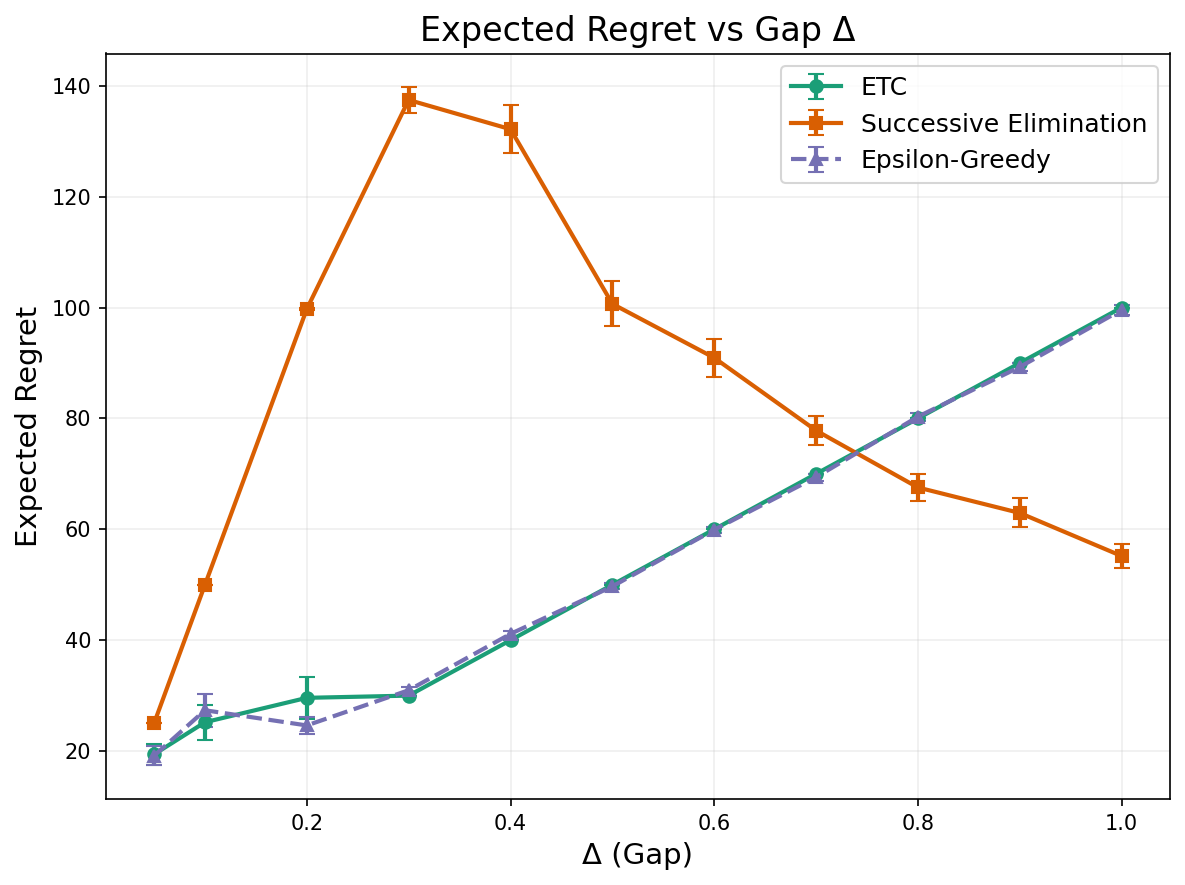

In [45]:
# Used ChatGPT to create the visualizations

colors = {
    "ETC": "#1b9e77",  # teal
    "Successive Elimination": "#d95f02",  # orange
    "Epsilon-Greedy": "#7570b3"  # purple
}

plt.figure(figsize=(8,6), dpi=150)

# ETC
plt.errorbar(
    gaps,
    avg_regrets_etc,
    yerr=stderr_etc,
    label="ETC",
    marker='o',
    linestyle='-',
    color=colors["ETC"],
    linewidth=2,
    markersize=6,
    capsize=4
)

# Successive Elimination
plt.errorbar(
    gaps,
    avg_regrets_se,
    yerr=stderr_se,
    label="Successive Elimination",
    marker='s',
    linestyle='-',
    color=colors["Successive Elimination"],
    linewidth=2,
    markersize=6,
    capsize=4
)

# Epsilon-Greedy
plt.errorbar(
    gaps,
    avg_regrets_eg,
    yerr=stderr_eg,
    label="Epsilon-Greedy",
    marker='^',
    linestyle='--',  # distinguish from ETC
    color=colors["Epsilon-Greedy"],
    linewidth=2,
    markersize=6,
    capsize=4
)

# Labels and title
plt.xlabel("Δ (Gap)", fontsize=14)
plt.ylabel("Expected Regret", fontsize=14)
plt.title("Expected Regret vs Gap Δ", fontsize=16)

# Legend
plt.legend(fontsize=12, frameon=True)

# Grid
plt.grid(alpha=0.2)

# Ensure layout is tight
plt.tight_layout()

plt.show()

# Part 3: Theoretical Analysis

### ETC Theoretical Upper Bound

In [61]:
m = int(np.ceil(n ** (2 / 3)))
R_etc = (gaps * m) + (gaps * (n - m) * np.exp(-((m * (gaps ** 2)) / 4)))

### Successive Elimination Theoretical Upper Bound

In [64]:
K = 2
b = 2
R_se = np.full(len(gaps), b * np.sqrt(K * n * np.log(n)))

### Epsilon Greedy Theoretical Upper Bound

In [72]:
b = 3
R_eg = b * ((c * gaps) + ((gaps * n) / c))

### Plotting Theoretical Upper Bounds

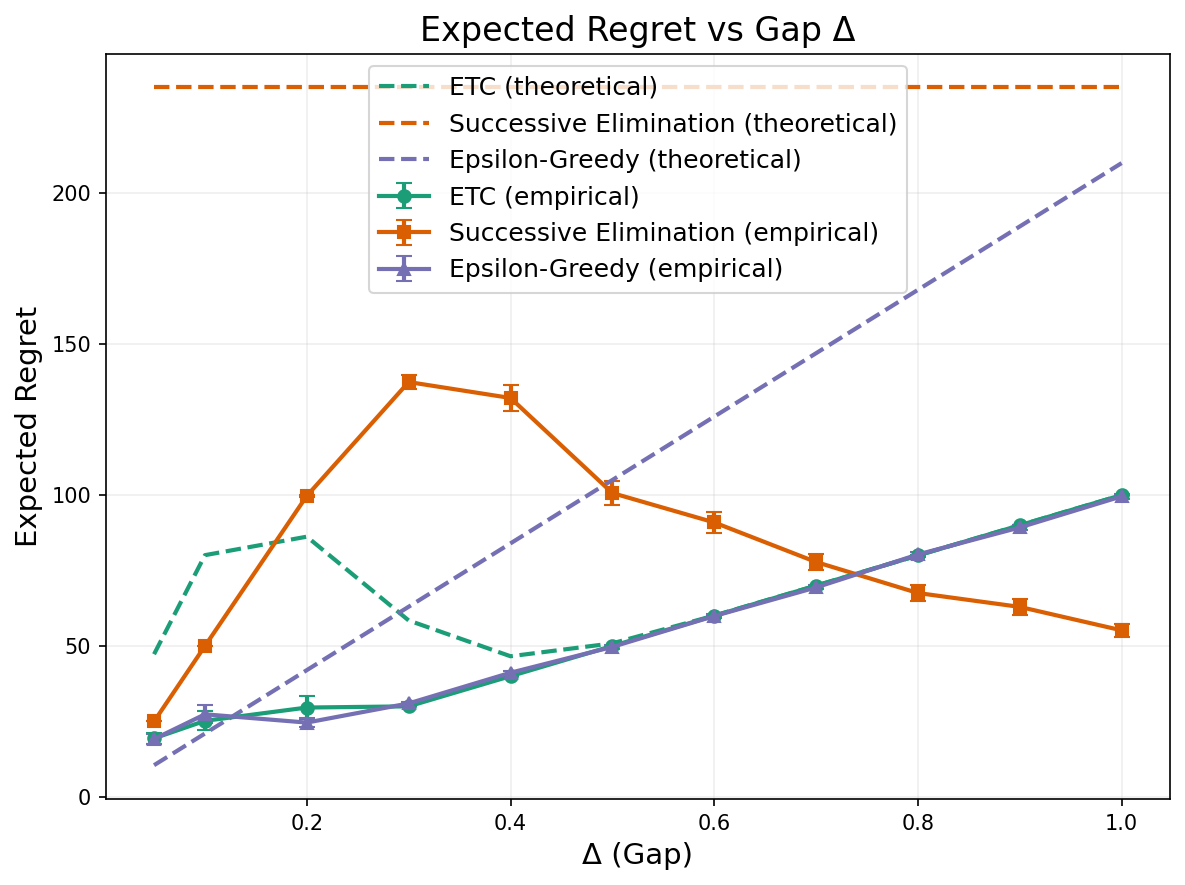

In [75]:
# Used ChatGPT to create the visualizations

# Add theoretical bounds to your existing plot
plt.figure(figsize=(8,6), dpi=150)

# Empirical curves (same as your code)
plt.errorbar(gaps, avg_regrets_etc, yerr=stderr_etc, label="ETC (empirical)",
             marker='o', linestyle='-', color=colors["ETC"], linewidth=2, markersize=6, capsize=4)
plt.errorbar(gaps, avg_regrets_se, yerr=stderr_se, label="Successive Elimination (empirical)",
             marker='s', linestyle='-', color=colors["Successive Elimination"], linewidth=2, markersize=6, capsize=4)
plt.errorbar(gaps, avg_regrets_eg, yerr=stderr_eg, label="Epsilon-Greedy (empirical)",
             marker='^', linestyle='-', color=colors["Epsilon-Greedy"], linewidth=2, markersize=6, capsize=4)

# Theoretical bounds (dashed lines)
plt.plot(gaps, R_etc, '--', color=colors["ETC"], label="ETC (theoretical)", linewidth=2)
plt.plot(gaps, R_se, '--', color=colors["Successive Elimination"], label="Successive Elimination (theoretical)", linewidth=2)
plt.plot(gaps, R_eg, '--', color=colors["Epsilon-Greedy"], label="Epsilon-Greedy (theoretical)", linewidth=2)

# Labels, title, legend
plt.xlabel("Δ (Gap)", fontsize=14)
plt.ylabel("Expected Regret", fontsize=14)
plt.title("Expected Regret vs Gap Δ", fontsize=16)
plt.legend(fontsize=12, frameon=True)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Part 4: Analysis and Discussion

### Compare the empirical performance of the three algorithms

For all algorithms, the expected regret starts off around 20. With Successive Elimination, the expected regret increases as $\Delta$ increases, hiting a maximum expected regret of around 140 when $\Delta = 0.3$. Increasing $\Delta = 0.3$ to $\Delta = 1.0$, the expected regret begins to decrease, reaching a expected regret of around 55 when $\Delta = 1.0$. As for standard errors, they start off too small to see but increase as $\Delta$ increases, reaching a maximum standard error when $\Delta = 0.6$. Increasing $\Delta = 0.6$ to $\Delta = 1.0$, the standard error decreases again, where it is too small to see when $\Delta = 1.0$.

With Explore-then-Commit (ETC), the expected regret increases as $\Delta$ increases. Between $\Delta = 0.1$ and $\Delta = 0.3$, the expected regret remains roughly the same but from $\Delta = 0.3$ to $\Delta = 1.0$, the expected regret increases linearly, reaching a maximum expected regret of about 100 when $\Delta = 1.0$. The standard errors tend to decrease as $\Delta$ increases, no longer being visible to the eye at larger values of $\Delta$. For $\Delta \geq 0.4$, the expected regret of ETC is very tight to the expected regret of $\epsilon-\text{greedy}$.

With $\epsilon-\text{greedy}$, the expected regret trend is very similar to that of ETC, which increases as the gap $\Delta$ increases, and in the interval between $\Delta = 0.1$ and $\Delta = 0.2$ the expected regret remains roughly the same. For values of $\Delta \geq 0.4$, the expected regret increases linearly, reaching a maximum expected regret of around 100 for $\Delta = 1.0$, exhibiting behavior very similar to ETC.

Regarding tightness of theoretical bounds, we first look at ETC. For ETC, there is a noticeable gap for values of $\Delta \leq 0.4$, but for $\Delta \geq 0.4$, it becomes difficult to distinguish the theoretical bound nad the expected regret of ETC. For $\epsilon-\text{greedy}$, the theoretical bound increases linearly and the gap between the expected regret and the theoretical upper bound increases as $\Delta$ increases. Lastly, with Successive Elimination, the theoretical bound is simply a flat line since it does not depend on $\Delta$ and thus, is not tight for all values of $\Delta$, except for the $\Delta$ which one could adjust the constant to make the bound coincide with the maximum empirical regret.

One interesting observation in this visualization is the peak of maximum regret at $\Delta = 0.3$ for successive elimination. An explanation for this could be because of the traeoff between $\Delta$ and exploration. For small values of $\Delta$ like $\Delta < 0.3$, the algorithm has to explore for longer before correctly identifying the optimal arm with high probability. However, since the gaps between the optimal arm and the suboptimal arm is relatively small, the expected regret is small to moderate. For intermediate values, the algorithm has still has to explore but not as much as those with small values of $\Delta$ to identify the optimal arm. However, since the gaps between the optimal arm and the suboptimal arm is larger, the expected regret is larger. Then, as $\Delta$ increases, the algorithm does not have to explore for as long to identify the optimal arm with high probability so the expected regret is less.

Another interesting observation is that the expected regret for both ETC and $\epsilon\text{-greedy}$ is roughly identical for $\Delta \geq 0.4$. A possible explanation for this observation is that for $\Delta \geq 0.4$, the gap between the optimal and suboptimal arm is large enough such that the algorithms can quickly identify the optimal arm and exploit it during exploitation. In $\epsilon\text{-greedy}$, the algorithm quickly learns the optimal arm and only incurs regret during exploration while in ETC, the algorithm quickly learns the optimal arm after exploration.